We estimate linear regression coefficients for the association between forest cover in the contiguous United States and two covariates: elevation and population. We compare map-only, GT-only ("classical"), and PPI methods.

We will do an "Error-in-X and -Y" regression. For forest cover and population, we use a map product along with a small calibration set of ground truth points. For elevation, we use ground truth for all points.  

Map product points and ground truth points are both from MOSAIKS paper dataset (Rolf et al, 2021): https://github.com/Global-Policy-Lab/mosaiks-paper

In [1]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.weightstats import _zconfint_generic
import statsmodels
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

# PPI for linear regression

The code for PPI for linear regression, as described in Section 2.2 of the paper, is given below. 

The main function is **bootstrap_ppi** which gives 100*(1-alpha) percent PPI confidence intervals for the regression coefficients. X and Y are the ground truth covariates and outcomes (respectively), Xhat and Yhat are the remotely sensed covariates and outcomes at the same locations as the ground truth, and Xhat_unlabeled and Yhat_unlabeled are a larger dataset of remotely sensed covariates and outcomes that do not have corresponding ground truth values available. 

Additionally, **classical_ols_ci** computes the 100*(1-alpha) percent GT-only confidence intervals.

In [2]:
def ppi_pointestimate(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, tuning_matrix):
    coeff_calibration = OLS(Y, exog=statsmodels.tools.add_constant(X)).fit().params
    coeff_preds_calibration = OLS(Yhat, exog=statsmodels.tools.add_constant(Xhat)).fit().params
    coeff_preds_all = OLS(Yhat_unlabeled, exog=statsmodels.tools.add_constant(Xhat_unlabeled)).fit().params
    
    coeff_ppi = tuning_matrix @ coeff_preds_all + (coeff_calibration - tuning_matrix @ coeff_preds_calibration)
    
    return coeff_ppi
    
def cross_cov(A, B):
    '''
    A is (p x n)
    B is (p x n)
    
    Output: (p x p) cross-covariance matrix
    '''
    n = A.shape[1]
    C = 1/(n-1) * (A-A.mean(axis=1)[:, np.newaxis]) @ (B-B.mean(axis=1)[:, np.newaxis]).T
    return C

def resample_datapoints(truth_X, preds_X, truth_Y, preds_Y, calibration_indices):
    # resample datapoints for a single bootstrap trial
    preds_indices = np.random.choice(np.arange(0, len(preds_X)), size=len(preds_X), replace=True)
    calibration_indices_resampled = preds_indices[np.isin(preds_indices, calibration_indices)]

    X_trial = truth_X[calibration_indices_resampled]
    Xhat_trial = preds_X[calibration_indices_resampled]
    Xhat_unlabeled_trial = preds_X[preds_indices]
    Y_trial = truth_Y[calibration_indices_resampled]
    Yhat_trial = preds_Y[calibration_indices_resampled]
    Yhat_unlabeled_trial = preds_Y[preds_indices]
    
    return X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial

def bootstrap_ppi(truth_X, preds_X, truth_Y, preds_Y, calibration_indices, tune=True, trials=100, alpha=0.05):
    
    if tune:
        # bootstrap to get tuning matrix
        coeff_calibration_list = []
        coeff_preds_calibration_list = []
        for trial in tqdm(range(trials)):
            X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial = resample_datapoints(truth_X, preds_X, truth_Y, preds_Y, calibration_indices)

            coeff_calibration = OLS(Y_trial, exog=statsmodels.tools.add_constant(X_trial)).fit().params
            coeff_calibration_list.append(coeff_calibration)

            coeff_preds_calibration = OLS(Yhat_trial, exog=statsmodels.tools.add_constant(Xhat_trial)).fit().params
            coeff_preds_calibration_list.append(coeff_preds_calibration)

        coeff_calibration_list = np.array(coeff_calibration_list).T
        coeff_preds_calibration_list = np.array(coeff_preds_calibration_list).T

        tuning_matrix = cross_cov(coeff_calibration_list, coeff_preds_calibration_list) @ np.linalg.inv(np.cov(coeff_preds_calibration_list))
    else:
        tuning_matrix = np.identity(X.shape[1]+1)
    
    # bootstrap to get confidence interval for coefficient
    outputs = []
    for trial in tqdm(range(trials)):
        X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial = resample_datapoints(truth_X, preds_X, truth_Y, preds_Y, calibration_indices)
        output = ppi_pointestimate(X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial, tuning_matrix)
        outputs.append(output)
        
    lo = np.percentile(outputs, 100*alpha/2, axis=0)
    hi = np.percentile(outputs, 100*(1-alpha/2), axis=0)
    return (lo, hi)

def classical_ols_ci(X, Y, alpha, alternative="two-sided"):
    regression = OLS(Y, exog=statsmodels.tools.add_constant(X)).fit()
    theta = regression.params
    se = regression.HC0_se
    ci = _zconfint_generic(theta, se, alpha, alternative)
    return (ci[0], ci[1])

# Load data

Load MOSAIKS datasets for forest cover, elevation, and population. After dropping points with missing variables, there are N=67968 total points. Each point has both ground truth and map product values in the original dataset.

For elevation, we will use ground truth data at all points. For forest cover and population, we will use the map product data (along with a small calibration set of points with both ground truth and map product).

In [3]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_treecover_treecover_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
tree_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_treecover_treecover_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
tree_data = pd.concat([tree_data, data])

tree_data = tree_data.rename(columns={"truth": "truth_tree", "preds": "preds_tree"})
tree_data = tree_data[['truth_tree', 'preds_tree', 'lon', 'lat']]

In [4]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_elevation_meters_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
elevation_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_elevation_meters_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
elevation_data = pd.concat([elevation_data, data])

elevation_data = elevation_data.rename(columns={"truth": "truth_elevation", "preds": "preds_elevation"})
elevation_data = elevation_data[['truth_elevation', 'preds_elevation', 'lon', 'lat']]

In [5]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_population_log_population_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
population_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_population_log_population_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
population_data = pd.concat([population_data, data])

population_data = population_data.rename(columns={"truth": "truth_population", "preds": "preds_population"})
population_data = population_data[['truth_population', 'preds_population', 'lon', 'lat']]

In [6]:
data = pd.merge(tree_data, elevation_data, on=['lon', 'lat'])
data = pd.merge(data, population_data, on=['lon', 'lat'])

In [7]:
# convert from m to km
data['truth_elevation'] = .001*data['truth_elevation']
data['preds_elevation'] = .001*data['preds_elevation']

In [8]:
data

,truth_tree,preds_tree,lon,lat,truth_elevation,preds_elevation,truth_population,preds_population
0,0.000000,0.000000,-119.794019,46.773157,0.423914,0.963784,0.290985,0.223613
1,0.000000,0.000000,-107.440142,36.628412,2.015408,1.779982,0.070059,1.089495
2,32.511176,42.111039,-87.580287,30.316254,0.005059,-0.016801,1.771785,2.923414
3,1.706111,0.000000,-102.316795,43.250483,1.000075,1.164283,2.654329,0.872536
4,34.121974,38.179145,-97.661712,29.815675,0.144380,0.310666,1.539581,1.788519
...,...,...,...,...,...,...,...,...
67963,0.056365,11.829323,-99.741350,32.537026,0.521323,0.422672,3.776049,3.563149
67964,1.926316,8.442633,-83.352149,41.014260,0.256471,0.174457,3.064954,2.710515
67965,2.947000,0.000000,-86.850348,36.650512,0.169112,0.125459,4.120613,3.165970
67966,0.084062,7.715938,-99.906619,31.509565,0.495074,0.488693,0.945092,1.091228


In [9]:
truth_Y = np.array(data['truth_tree']).reshape(-1, 1)
preds_Y = np.array(data['preds_tree']).reshape(-1, 1)

truth_X = np.array(data[['truth_elevation', 'truth_population']])
preds_X = np.array(data[['truth_elevation', 'preds_population']])

# TRUE THETA
true_coeff = OLS(truth_Y, exog=statsmodels.tools.add_constant(truth_X)).fit().params
print(true_coeff)

[ 31.80598858 -12.25842547   1.37923979]


In [10]:
# THETA FROM PREDICTED X and Y
map_only_coeff = OLS(preds_Y, exog=statsmodels.tools.add_constant(preds_X)).fit().params
print(map_only_coeff)

[29.71662976 -9.93941771  2.03193753]


# Linear regression coefficient estimation

We randomly choose n=500 of the points to be the calibration set (both ground truth and map product data available), and treat the rest of the points as if only map product data is available. 

We compute map-only, GT-only (classical), and PPI 95% confidence intervals (for each covariate). 

In [11]:
classical_estimates = []
classical_ci_widths = []
classical_ci_contains_true_theta = []

ppi_estimates = []
ppi_ci_widths = []
ppi_ci_contains_true_theta = []

np.random.seed(seed=0)
calibration_indices = np.random.choice(np.arange(0, len(data)), size=500, replace=True)

ppi_ci = bootstrap_ppi(truth_X, preds_X, truth_Y, preds_Y, calibration_indices, trials=2000, alpha=0.05)
classical_ci = classical_ols_ci(truth_X[calibration_indices], truth_Y[calibration_indices], alpha=0.05)

ppi_estimates.append(0.5*(ppi_ci[0] + ppi_ci[1]))
classical_estimates.append(0.5*(classical_ci[0] + classical_ci[1]))

ppi_ci_widths.append(ppi_ci[1] - ppi_ci[0])
classical_ci_widths.append(classical_ci[1] - classical_ci[0])

ppi_ci_contains_true_theta.append(np.logical_and(np.greater(true_coeff, ppi_ci[0]), np.less(true_coeff, ppi_ci[1])))
classical_ci_contains_true_theta.append(np.logical_and(np.greater(true_coeff, classical_ci[0]), np.less(true_coeff, classical_ci[1])))

100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:44<00:00, 44.60it/s]


In [12]:
map_only_ci = classical_ols_ci(preds_X, preds_Y, alpha=0.05)
map_only_estimates = 0.5*(map_only_ci[0] + map_only_ci[1])
map_only_widths = map_only_ci[1] - map_only_ci[0]

# Visualize results for paper

In [13]:
plt.rcParams["font.sans-serif"] = "Arial"

plt.rc('font', size=43)          
plt.rc('axes', titlesize=43)     
plt.rc('axes', labelsize=43)    
plt.rc('xtick', labelsize=43)    
plt.rc('ytick', labelsize=43)    
plt.rc('figure', titlesize=43)

In [14]:
covariates = ['Intercept', 'Elevation', 'Population']
classical_dict = {}
ppi_dict = {}
for i in range(len(covariates)):
    covariate = covariates[i]
    classical_dict[f"{covariate} Coeff Estimate"] = np.array(classical_estimates)[:, i]
    classical_dict[f"{covariate} CI width"] = np.array(classical_ci_widths)[:, i]
    ppi_dict[f"{covariate} Coeff Estimate"] = np.array(ppi_estimates)[:, i]
    ppi_dict[f"{covariate} CI width"] = np.array(ppi_ci_widths)[:, i]
    
classical_df = pd.DataFrame(classical_dict)
classical_df['Method'] = 'Classical'

ppi_df = pd.DataFrame(ppi_dict)
ppi_df['Method'] = 'PPI'

df = pd.concat([classical_df, ppi_df], ignore_index=True)

,category,lower,upper
0,PPI (Map + GT),28.934009,34.818708
1,GT-only,27.738579,39.468431
2,Map-only,29.206215,30.227045


,category,lower,upper
0,PPI (Map + GT),-14.700432,-10.929202
1,GT-only,-18.831166,-9.147340
2,Map-only,-10.292065,-9.586771


,category,lower,upper
0,PPI (Map + GT),0.152533,2.342567
1,GT-only,-1.247234,1.839589
2,Map-only,1.870562,2.193313


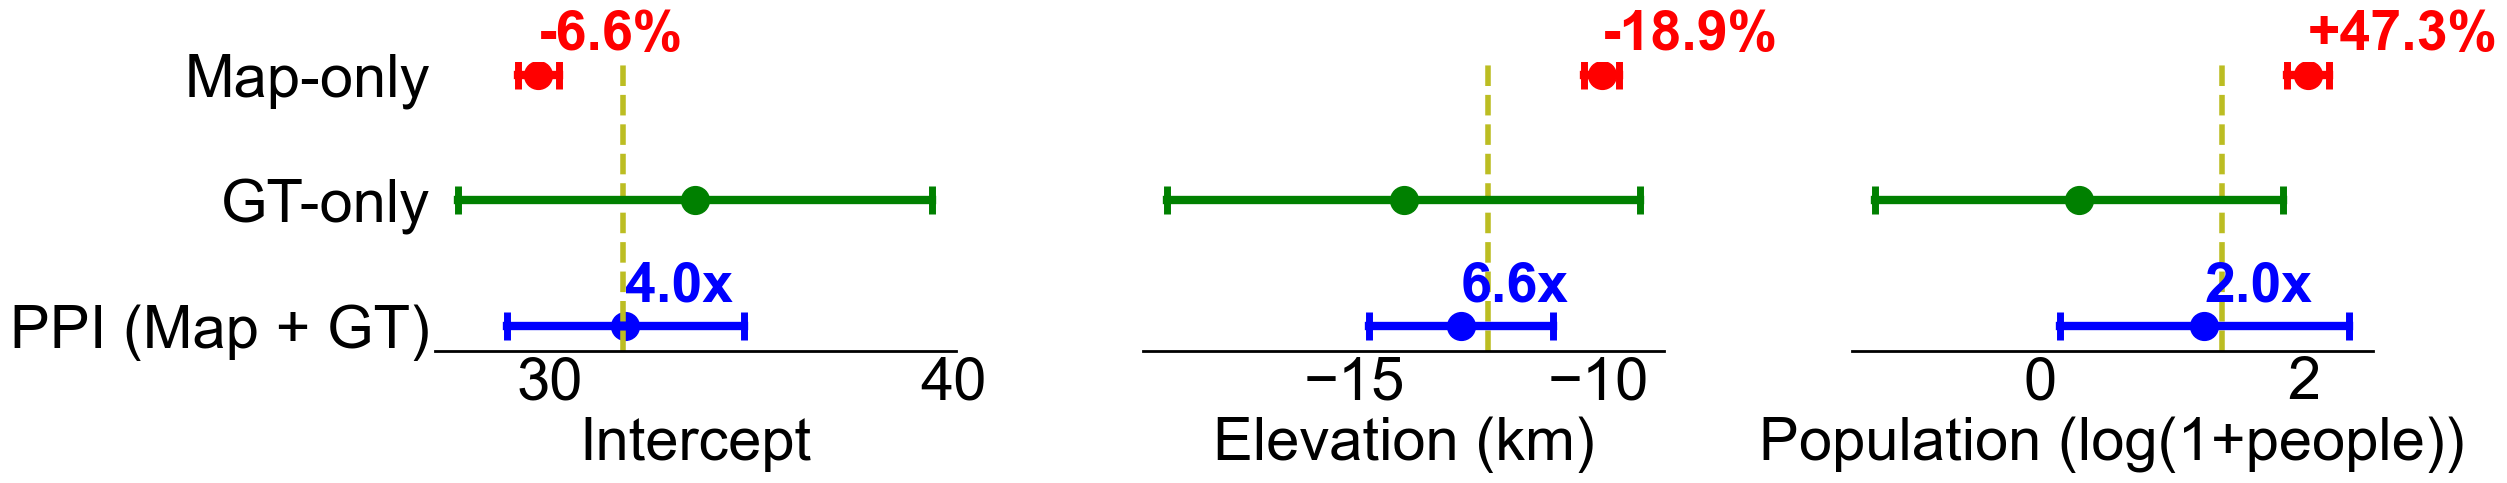

In [15]:
ppi_avg_estimates = np.array(ppi_estimates).mean(axis=0)
ppi_avg_widths = np.array(ppi_ci_widths).mean(axis=0)

classical_avg_estimates = np.array(classical_estimates).mean(axis=0)
classical_avg_widths = np.array(classical_ci_widths).mean(axis=0)

covariates_dict = {'Intercept': 'Intercept', 
                   'Elevation': 'Elevation (km)', 
                   'Population': 'Population (log(1+people))'}

# https://stackoverflow.com/questions/59747313/how-can-i-plot-a-confidence-interval-in-python
fig = plt.figure(figsize=(32, 6))
colors = ['blue', 'green', 'red']
for i, column in enumerate(covariates):
        
    data_dict = {}
    ppi_effective_n = int(np.round(len(calibration_indices)*(classical_avg_widths[i]/ppi_avg_widths[i])**2))
    data_dict['category'] = ['PPI (Map + GT)',
                             'GT-only',
                             'Map-only']
    data_dict['lower'] = [ppi_avg_estimates[i] - ppi_avg_widths[i]/2, classical_avg_estimates[i] - classical_avg_widths[i]/2, map_only_estimates[i] - map_only_widths[i]/2]
    data_dict['upper'] = [ppi_avg_estimates[i] + ppi_avg_widths[i]/2, classical_avg_estimates[i] + classical_avg_widths[i]/2, map_only_estimates[i] + map_only_widths[i]/2]
    dataset = pd.DataFrame(data_dict)
    
    display(dataset)
    
    subplot = fig.add_subplot(141+i)
    #ax = subplot.gca()
    subplot.spines['top'].set_visible(False)
    subplot.spines['right'].set_visible(False)
    subplot.spines['left'].set_visible(False)
    subplot.spines['bottom'].set_linewidth(2)
    
    # show true coefficient
    subplot.axvline(true_coeff[i], color='tab:olive', linestyle='--', lw=4, label='True \ncoefficient')
    '''
    if i == 2:
        subplot.legend(prop={'size':40}, loc=(0.9, 0.9))
    '''

    for lower,upper,y in zip(dataset['lower'],dataset['upper'],range(len(dataset))):
        subplot.scatter([(lower+upper)/2], [y], color=colors[y], s=400)
        subplot.scatter([lower, upper], [y, y], color=colors[y], marker='|', s=400, lw=5)
        subplot.plot((lower,upper),(y,y),color=colors[y], lw=6)
        if y == 0:
            # compute PPI effective sample size improvement over GT-only
            ppi_effective_n = np.round(ppi_effective_n/len(calibration_indices), 1)
            subplot.text((lower+upper)/2, 0.2, f'{ppi_effective_n}x', fontsize = 40, c='blue', weight='bold')
        if y == 2:
            # compute map-only estimate bias
            map_only_bias = np.round(100*(map_only_estimates[i] - true_coeff[i])/true_coeff[i], 1) 
            subplot.text((lower+upper)/2, 2.2, f'{map_only_bias:+g}%', fontsize = 40, c='red', weight='bold')
            
    subplot.tick_params(axis=u'both', which=u'both',length=0)
    if i == 0:
        subplot.set_yticks(range(len(dataset)),list(dataset['category']))
    else:
        subplot.set_yticks([])
    subplot.set_xlabel(f'{covariates_dict[column]}')
    subplot.set_ylim(-0.2)
    
plt.tight_layout()    
plt.savefig(f'output_images/forest_cover_lin_reg_all.png', dpi=300, bbox_inches='tight')
plt.show()

# Motivating example figure (for Introduction of paper)

,category,lower,upper
0,PPI (Map + GT),-14.700432,-10.929202
1,Ground Truth-only,-18.831166,-9.147340
2,Map-only,-10.292065,-9.586771


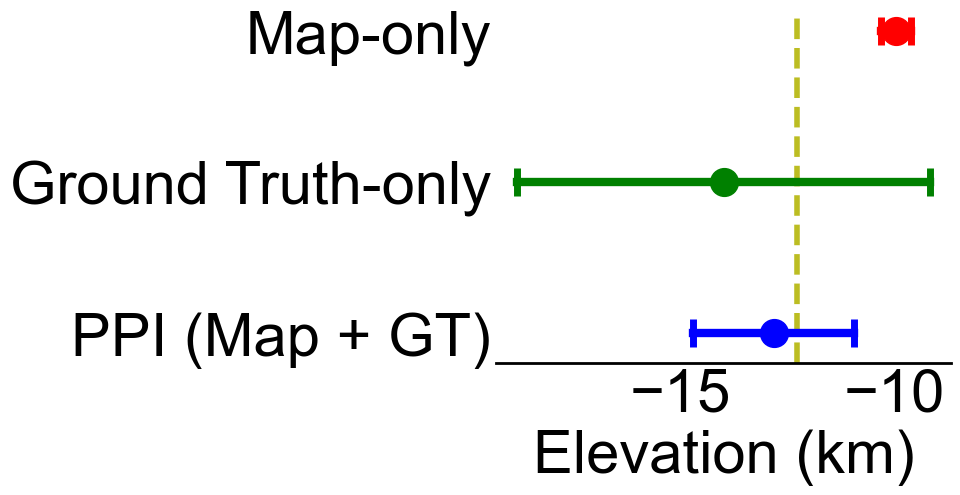

In [17]:
ppi_avg_estimates = np.array(ppi_estimates).mean(axis=0)
ppi_avg_widths = np.array(ppi_ci_widths).mean(axis=0)

classical_avg_estimates = np.array(classical_estimates).mean(axis=0)
classical_avg_widths = np.array(classical_ci_widths).mean(axis=0)

covariates_dict = {'Intercept': 'Intercept', 
                   'Elevation': 'Elevation (km)', 
                   'Population': 'Population (log(1+people))'}

# https://stackoverflow.com/questions/59747313/how-can-i-plot-a-confidence-interval-in-python
fig = plt.figure(figsize=(36, 6))
colors = ['blue', 'green', 'red']
for i, column in enumerate(covariates):
    
    if column=='Elevation':
        
        data_dict = {}
        ppi_effective_n = int(np.round(len(calibration_indices)*(classical_avg_widths[i]/ppi_avg_widths[i])**2))
        data_dict['category'] = ['PPI (Map + GT)',
                                 'Ground Truth-only',
                                 'Map-only']
        data_dict['lower'] = [ppi_avg_estimates[i] - ppi_avg_widths[i]/2, classical_avg_estimates[i] - classical_avg_widths[i]/2, map_only_estimates[i] - map_only_widths[i]/2]
        data_dict['upper'] = [ppi_avg_estimates[i] + ppi_avg_widths[i]/2, classical_avg_estimates[i] + classical_avg_widths[i]/2, map_only_estimates[i] + map_only_widths[i]/2]
        dataset = pd.DataFrame(data_dict)

        display(dataset)

        subplot = fig.add_subplot(141+i)
        #ax = subplot.gca()
        subplot.spines['top'].set_visible(False)
        subplot.spines['right'].set_visible(False)
        subplot.spines['left'].set_visible(False)
        subplot.spines['bottom'].set_linewidth(2)

        # show true coefficient
        subplot.axvline(true_coeff[i], color='tab:olive', linestyle='--', lw=4, label='True \ncoefficient')
        '''
        if i == 2:
            subplot.legend(prop={'size':40}, loc=(0.9, 0.9))
        '''

        for lower,upper,y in zip(dataset['lower'],dataset['upper'],range(len(dataset))):
            subplot.scatter([(lower+upper)/2], [y], color=colors[y], s=400)
            subplot.scatter([lower, upper], [y, y], color=colors[y], marker='|', s=400, lw=5)
            subplot.plot((lower,upper),(y,y),color=colors[y], lw=6)

        subplot.tick_params(axis=u'both', which=u'both',length=0)
        subplot.set_yticks(range(len(dataset)),list(dataset['category']))

        subplot.set_xlabel(f'{covariates_dict[column]}')
        subplot.set_ylim(-0.2)
    
plt.tight_layout()    
plt.savefig(f'output_images/motivating_example.png', dpi=300, bbox_inches='tight')
plt.show()

# Point estimates for elevation coefficient over 100 trials

In [18]:
classical_estimates = []
classical_ci_widths = []
classical_ci_contains_true_theta = []

ppi_estimates = []
ppi_ci_widths = []
ppi_ci_contains_true_theta = []

for i in range(100):
    np.random.seed(seed=i)
    calibration_indices = np.random.choice(np.arange(0, len(data)), size=500, replace=True)

    ppi_ci = bootstrap_ppi(truth_X, preds_X, truth_Y, preds_Y, calibration_indices, trials=2000, alpha=0.05)
    classical_ci = classical_ols_ci(truth_X[calibration_indices], truth_Y[calibration_indices], alpha=0.05)

    ppi_estimates.append(0.5*(ppi_ci[0] + ppi_ci[1]))
    classical_estimates.append(0.5*(classical_ci[0] + classical_ci[1]))

    ppi_ci_widths.append(ppi_ci[1] - ppi_ci[0])
    classical_ci_widths.append(classical_ci[1] - classical_ci[0])

    ppi_ci_contains_true_theta.append(np.logical_and(np.greater(true_coeff, ppi_ci[0]), np.less(true_coeff, ppi_ci[1])))
    classical_ci_contains_true_theta.append(np.logical_and(np.greater(true_coeff, classical_ci[0]), np.less(true_coeff, classical_ci[1])))

100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:47<00:00, 41.89it/s]


100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:45<00:00, 44.39it/s]


100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:47<00:00, 41.97it/s]


In [19]:
map_only_ci = classical_ols_ci(preds_X, preds_Y, alpha=0.05)
map_only_estimates = 0.5*(map_only_ci[0] + map_only_ci[1])
map_only_widths = map_only_ci[1] - map_only_ci[0]

In [20]:
ppi_estimates

[array([ 31.8763588 , -12.81481717,   1.2475503 ]),
 array([ 34.93254011, -13.99648188,   0.17321818]),
 array([ 33.10821128, -13.18967226,   0.78747698]),
 array([ 33.426172  , -12.06011482,   0.60372375]),
 array([ 30.98741505, -11.7925172 ,   1.44335926]),
 array([ 30.76954067, -12.15381357,   1.10464858]),
 array([ 32.46638691, -12.49028327,   1.40378719]),
 array([ 32.13491101, -12.84999178,   1.15006634]),
 array([ 32.79580408, -12.81849363,   1.17183975]),
 array([ 33.07251938, -13.81793479,   0.86089489]),
 array([ 31.40042143, -11.20156795,   1.75731287]),
 array([ 32.19997066, -12.07451125,   1.1240971 ]),
 array([ 31.09444045, -12.12875618,   1.62338999]),
 array([ 32.46554008, -12.32161276,   0.91577324]),
 array([ 31.49360189, -11.88512906,   1.52106291]),
 array([ 33.27487522, -13.44905868,   0.76181672]),
 array([ 31.511658  , -12.45731442,   1.31524506]),
 array([ 31.52401281, -12.44579163,   1.44582534]),
 array([ 30.75578292, -10.81624659,   1.78522954]),
 array([ 32.

In [21]:
classical_estimates

[array([ 33.60350517, -13.98925325,   0.29617747]),
 array([ 37.13842567, -14.66496429,  -0.07966661]),
 array([ 29.79520163, -10.6590863 ,   1.66168464]),
 array([ 32.99702678, -13.94312959,   1.01054756]),
 array([ 32.91581503, -16.44463576,   2.47724652]),
 array([ 27.79723793, -11.2933753 ,   1.43111073]),
 array([ 36.74014381, -15.56027963,   0.389409  ]),
 array([ 34.58446947, -14.22961303,  -0.18699055]),
 array([ 30.51888441, -12.14553552,   2.13136901]),
 array([ 29.9303354 , -13.31102718,   1.60320004]),
 array([ 34.86876219, -14.84718733,   1.22273206]),
 array([ 29.18388097, -10.54696642,   1.98496373]),
 array([ 31.84582764, -13.45894666,   2.16889731]),
 array([ 36.51084584, -16.85429226,   0.15414239]),
 array([ 34.24534631, -10.94674166,   0.18344456]),
 array([ 30.54916796, -10.30102691,   1.28169962]),
 array([ 33.41027734, -13.36355519,   0.3343841 ]),
 array([ 29.73043835, -10.37845477,   0.95387249]),
 array([29.07438896, -9.76940426,  1.88179118]),
 array([ 29.659

In [22]:
print(np.min(np.array(ppi_estimates)[:, 1]))
print(np.max(np.array(ppi_estimates)[:, 1]))
print(np.min(np.array(classical_estimates)[:, 1]))
print(np.max(np.array(classical_estimates)[:, 1]))
print(map_only_estimates[1])

-15.67993249528911
-9.325166318243411
-18.273900145229213
-7.099773516978212
-9.939417713069698


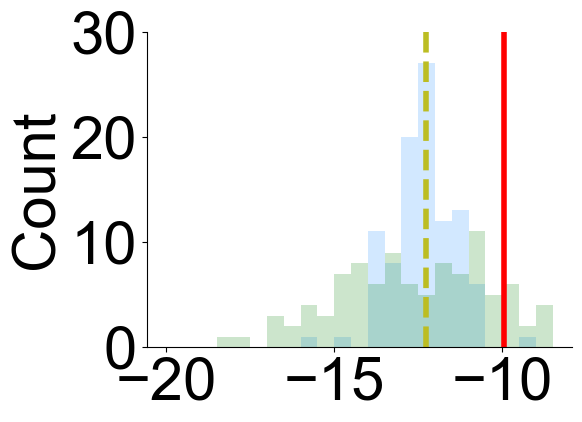

In [23]:
plt.rcParams["font.sans-serif"] = "Arial"

plt.rc('font', size=26) 

ax = plt.subplot(111)

bins = np.arange(-20, -8, 0.5)
ax.hist(np.array(ppi_estimates)[:, 1], bins, alpha=0.2, color='dodgerblue', label='PPI')
ax.hist(np.array(classical_estimates)[:, 1], bins, alpha=0.2, color='green', label='Ground Truth-only')
ax.axvline(map_only_estimates[1], color='red', lw=4, label='Map-only')
ax.axvline(true_coeff[1], color='tab:olive', linestyle='--', lw=4, label='True coefficient')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(np.arange(-20, -5, 5))
plt.yticks(np.arange(0, 32, 10))

plt.ylabel("Count")

#ax.legend(loc=2, prop={'size': 16})
    
plt.tight_layout()    
plt.savefig(f'output_images/motivating_example_histogram.png', dpi=300, bbox_inches='tight')
plt.show()